# SeedSec Rwanda: Maize Seed Vigor Detection Training Notebook
This Jupyter notebook sets up the workspace, downloads, unzips, structures, and trains a **YOLOv8** model for Maize Seed Vigor Stage Classification/Object Detection using the Kaggle dataset uploaded to Google Drive.

### Workflow:
1. **Google Drive Mount & API Key Configuration**
2. **Dependencies & Environment Setup** (install PyTorch, ultralytics)
3. **Dataset Verification & Structuring** (unpack and parse XML annotations to YOLO `.txt` format)
4. **Data Config Yaml Creation**
5. **Model Training** (YOLOv8 Training)
6. **Model Verification & Testing**
7. **TFLite Export** (for offline edge execution)

## Step 1: Set Kaggle Token & Mount Google Drive

In [ ]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 2: Install Libraries & Verify Dataset Location

In [ ]:
# Install Ultralytics for YOLOv8
!pip install ultralytics -q

# Verify dataset directory contents
dataset_dir = "/content/drive/MyDrive/KaggleDatasets/seed-vigor-detection"
print("Checking contents of dataset directory:")
!ls -la "$dataset_dir"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 69.9 MB/s eta 0:00:00
Checking contents of dataset directory:
total 66523465
drwx------ 2 root root        4096 Jun  2 10:38 1
drwx------ 2 root root        4096 Jun  2 10:38 10
drwx------ 2 root root        4096 Jun  2 10:39 100
drwx------ 2 root root        4096 Jun  2 10:39 101
drwx------ 2 root root        4096 Jun  2 10:40 102
drwx------ 2 root root        4096 Jun  2 10:40 103
drwx------ 2 root root        4096 Jun  2 10:41 104
drwx------ 2 root root        4096 Jun  2 10:41 105
drwx------ 2 root root        4096 Jun  2 10:42 106
drwx------ 2 root root        4096 Jun  2 10:42 107
drwx------ 2 root root        4096 Jun  2 10:43 108
drwx------ 2 root root        4096 Jun  2 10:44 109
drwx------ 2 root root        4096 Jun  2 10:44 11
drwx------ 2 root root        4096 Jun  2 10:45 110
drwx------ 2 root root        4096 Jun  2 10:45 111
drwx------ 2

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/KaggleDatasets/seed-vigor-detection/seed-vigor-detection-rgb-image.zip"
extract_path = "/content/drive/MyDrive/KaggleDatasets/seed-vigor-detection" # Extract directly to Google Drive

# Check if a representative extracted directory exists (e.g., 'Annotations')
# This avoids re-unzipping if the data is already there
if not os.path.exists(os.path.join(extract_path, 'Annotations')):
    if os.path.exists(zip_path):
        print(f"Unzipping {zip_path} to {extract_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("Unzipping complete.")
    else:
        print(f"Zip file not found at {zip_path}. Please ensure it exists.")
else:
    print(f"Dataset appears to be already unzipped in {extract_path}. Skipping unzipping.")

Dataset appears to be already unzipped in /content/drive/MyDrive/KaggleDatasets/seed-vigor-detection. Skipping unzipping.


### Note on Directory Structure
Now that we've extracted the files, we need to ensure `source_dir` in the next cell points to the location where the `.jpg` and `.xml` files actually reside (likely inside `/content/dataset_extracted` or a subfolder within it).

## Step 3: Convert Annotations & Organize Dataset for YOLO
YOLOv8 requires dataset splitting into `images/` and `labels/` subfolders for `train` and `val` sets, and annotations must be in Normalized YOLO format (`.txt` files containing: `<class_id> <x_center> <y_center> <width> <height>`).

This cell parses the XML files (from PASCAL VOC format) and structures the directories correctly.

In [ ]:
import xml.etree.ElementTree as ET
import glob
import shutil
import random
from pathlib import Path

# Paths configuration
source_dir = Path("/content/drive/MyDrive/KaggleDatasets/seed-vigor-detection")

# --- SEARCH FOR XMLs ---
print("Searching for XML files...")
# Try to find any XML file in the dataset directory to identify the correct folder
search_results = glob.glob(str(source_dir / "**" / "*.xml"), recursive=True)
if search_results:
    xml_folder = Path(search_results[0]).parent
    print(f"Detected XML folder at: {xml_folder}")
else:
    print("CRITICAL: No XML files found anywhere in the source directory!")
    xml_folder = source_dir / "Annotations" # Fallback

yolo_dataset_dir = Path("/content/seed_vigor_yolo_format")

# Define target subdirectories
for split in ["train", "val"]:
    (yolo_dataset_dir / "images" / split).mkdir(parents=True, exist_ok=True)
    (yolo_dataset_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

# Classes mapping
class_mapping = {"ungerminated": 0, "germinated": 1, "vigor_1": 2, "vigor_2": 3, "vigor_3": 4}
discovered_classes = set()

def convert_xml_to_yolo(xml_file, output_txt_path, img_width, img_height):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        size = root.find("size")
        if size is not None:
            img_width = int(size.find("width").text) or img_width
            img_height = int(size.find("height").text) or img_height
        lines = []
        for obj in root.findall("object"):
            class_name = obj.find("name").text.strip().lower()
            discovered_classes.add(class_name)
            if class_name not in class_mapping:
                class_mapping[class_name] = len(class_mapping)
            class_id = class_mapping[class_name]
            bbox = obj.find("bndbox")
            xmin, ymin = float(bbox.find("xmin").text), float(bbox.find("ymin").text)
            xmax, ymax = float(bbox.find("xmax").text), float(bbox.find("ymax").text)
            x_center = ((xmin + xmax) / 2.0) / img_width
            y_center = ((ymin + ymax) / 2.0) / img_height
            width = (xmax - xmin) / img_width
            height = (ymax - ymin) / img_height
            lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")
        with open(output_txt_path, "w") as f:
            f.write("\n".join(lines))
    except Exception as e:
        print(f"Error processing {xml_file}: {e}")

# Gather all image files
all_image_files = sorted(glob.glob(str(source_dir / "**" / "*.jpg"), recursive=True) +
                         glob.glob(str(source_dir / "**" / "*.png"), recursive=True))

# Gather all XML files from the detected folder
all_xml_files = sorted(glob.glob(str(xml_folder / "*.xml")))

print(f"Images found: {len(all_image_files)}")
print(f"XMLs found: {len(all_xml_files)}")

# Match images with XMLs
dataset_pairs = []
xml_map = {Path(x).stem: Path(x) for x in all_xml_files}
for img_path_str in all_image_files:
    img_path = Path(img_path_str)
    if img_path.stem in xml_map:
        dataset_pairs.append((img_path, xml_map[img_path.stem]))

print(f"Paired sets: {len(dataset_pairs)}")

if len(dataset_pairs) > 0:
    random.seed(42)
    random.shuffle(dataset_pairs)
    split_idx = int(len(dataset_pairs) * 0.8)
    train_pairs, val_pairs = dataset_pairs[:split_idx], dataset_pairs[split_idx:]

    def process_pairs(pairs, split_name):
        for img_path, xml_path in pairs:
            shutil.copy(str(img_path), yolo_dataset_dir / "images" / split_name / img_path.name)
            convert_xml_to_yolo(xml_path, yolo_dataset_dir / "labels" / split_name / f"{img_path.stem}.txt", 640, 640)
        print(f"Done {split_name}")

    process_pairs(train_pairs, "train")
    process_pairs(val_pairs, "val")
    print("Classes:", list(discovered_classes))
else:
    print("No pairs found. Please check if file names in 'Annotations' match the image file names exactly (ignoring extensions).")

Searching for XML files...
Detected XML folder at: /content/drive/MyDrive/KaggleDatasets/seed-vigor-detection/Annotations/Annotations/1
Images found: 18125
XMLs found: 165
Paired sets: 165
Done train
Done val
Classes: ['primary root', 'ungerminated', 'secondary root', 'germinated', 'germinating']


## Step 4: Create YOLOv8 Config File (`dataset.yaml`)
Ultralytics YOLO uses a YAML file specifying the dataset root directory, subdirectories for training/validation subsets, classes dictionary, and number of classes.

In [ ]:
import yaml

# Construct dynamic dataset YAML structure
classes_list = sorted(class_mapping.items(), key=lambda x: x[1])
classes_names = {idx: name for name, idx in classes_list}

yaml_content = {
    "path": "/content/seed_vigor_yolo_format",
    "train": "images/train",
    "val": "images/val",
    "names": classes_names
}

yaml_file_path = "/content/seed_vigor_yolo_format/dataset.yaml"
with open(yaml_file_path, "w") as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print("Created dataset.yaml content:")
with open(yaml_file_path, "r") as f:
    print(f.read())

Created dataset.yaml content:
names:
  0: ungerminated
  1: germinated
  2: vigor_1
  3: vigor_2
  4: vigor_3
path: /content/seed_vigor_yolo_format
train: images/train
val: images/val



## Step 5: Initialize and Train YOLOv8 Model
We will use YOLOv8n (YOLOv8 Nano, lightweight for later translation to mobile) loaded with pre-trained weights for transfer learning, training for 50 epochs.

In [ ]:
from ultralytics import YOLO

# Load pre-trained nano detector
model = YOLO("yolov8n.pt")

# Begin training run
results = model.train(
    data="/content/seed_vigor_yolo_format/dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/drive/MyDrive/KaggleDatasets/seed-vigor-detection/runs",
    name="seed_vigor_detection_yolov8"
)

print("Training completed! Run weights saved in your Google Drive.")

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/seed_vigor_yolo_format/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seed_vigor_detection_yolov8-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

In [ ]:
from ultralytics import YOLO

# Load pre-trained nano detector
model = YOLO("yolov8n.pt")

# Begin training run
results = model.train(
    data="/content/seed_vigor_yolo_format/dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/drive/MyDrive/KaggleDatasets/seed-vigor-detection/runs",
    name="seed_vigor_detection_yolov8"
)

print("Training completed! Run weights saved in your Google Drive.")

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/seed_vigor_yolo_format/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seed_vigor_detection_yolov8-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

### Training Metrics Visualization
This section plots the training/validation losses and the mean Average Precision (mAP) to evaluate the model's performance over time.

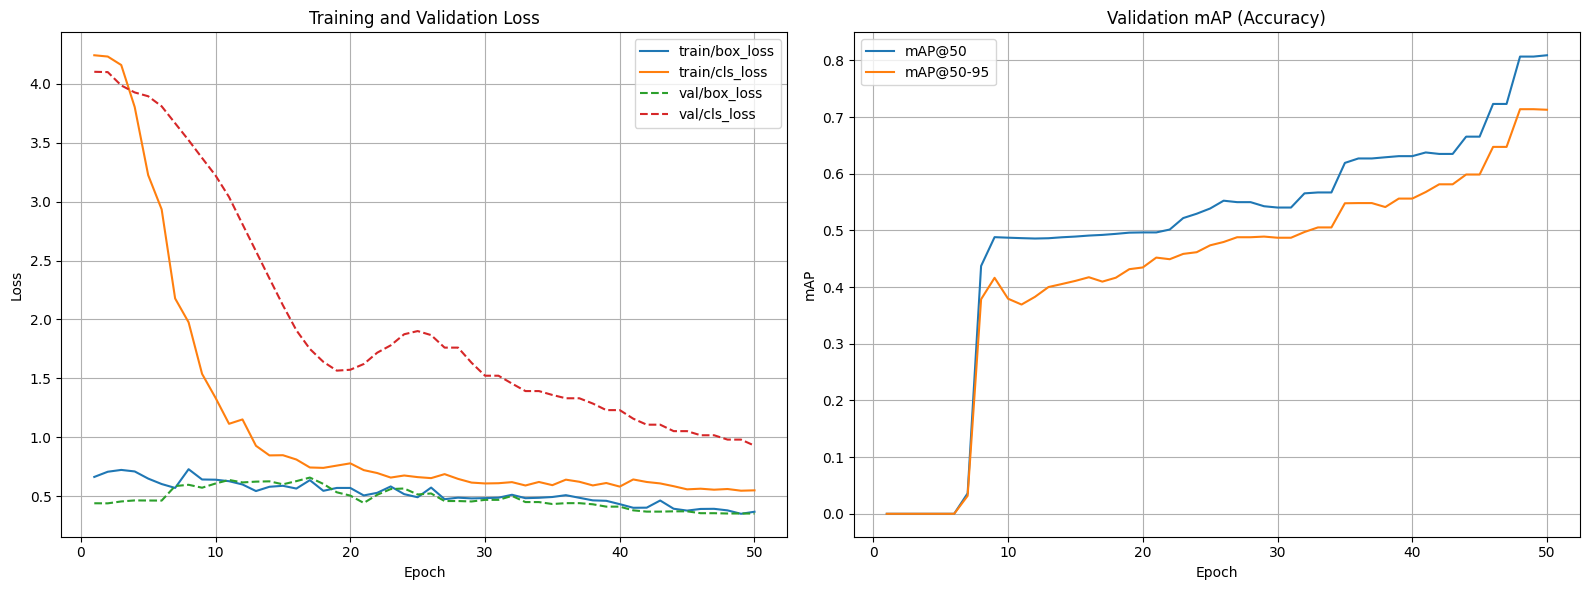

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Path to the results.csv file generated by YOLOv8
# We fetch the latest run directory
run_dir = results.save_dir
results_csv = os.path.join(run_dir, 'results.csv')

if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    # Plot Losses
    axs[0].plot(df['epoch'], df['train/box_loss'], label='train/box_loss')
    axs[0].plot(df['epoch'], df['train/cls_loss'], label='train/cls_loss')
    axs[0].plot(df['epoch'], df['val/box_loss'], label='val/box_loss', linestyle='--')
    axs[0].plot(df['epoch'], df['val/cls_loss'], label='val/cls_loss', linestyle='--')
    axs[0].set_title('Training and Validation Loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # Plot mAP (Accuracy Metrics)
    axs[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50')
    axs[1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95')
    axs[1].set_title('Validation mAP (Accuracy)')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('mAP')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()
else:
    print(f'Results file not found at {results_csv}. Check your training run directory.')

## Step 6: Validate & Export Model to TFLite (for Offline App)
Once trained, we validate the model on the validation set, verify precision and recall metrics, and export the best checkpoint to TensorFlow Lite format (with FP16 quantization).

In [ ]:
import os
from ultralytics import YOLO
import shutil

# Dynamically get the path to the best weights from the latest training run
best_weights_path = os.path.join(results.save_dir, 'weights', 'best.pt')
print(f"Loading best model from: {best_weights_path}")

best_model = YOLO(best_weights_path)

# Validate performance
metrics = best_model.val()
print(f"mAP50-95 score: {metrics.box.map:.4f}")
print(f"mAP50 score: {metrics.box.map50:.4f}")

# Export to TFLite (quantized FP16)
print("Exporting model to quantized TFLite...")
tflite_path = best_model.export(format="tflite", int8=False, half=True)
print(f"Model exported successfully! TFLite path: {tflite_path}")

# Copy exported weights directly to dataset workspace on Drive
destination_path = "/content/drive/MyDrive/KaggleDatasets/seed-vigor-detection/best_seed_vigor_fp16.tflite"
shutil.copy(tflite_path, destination_path)
print(f"Saved TFLite model to Google Drive at: {destination_path}")

Loading best model from: /content/drive/MyDrive/KaggleDatasets/seed-vigor-detection/runs/seed_vigor_detection_yolov8-3/weights/best.pt
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2818.9±1499.8 MB/s, size: 8516.2 KB)
val: Scanning /content/seed_vigor_yolo_format/labels/val.cache... 33 images, 0 backgrounds, 24 corrupt: 100% ━━━━━━━━━━━━ 33/33 8.1Mit/s 0.0s
val: /content/seed_vigor_yolo_format/images/val/IMG_20230322_230038.jpg: corrupt JPEG restored and saved
val: /content/seed_vigor_yolo_format/images/val/IMG_20230323_040011.jpg: corrupt JPEG restored and saved
val: /content/seed_vigor_yolo_format/images/val/IMG_20230323_050008.jpg: corrupt JPEG restored and saved
val: /content/seed_vigor_yolo_format/images/val/IMG_20230323_060006.jpg: corrupt JPEG restored and saved
val: /content/seed_vigor_yolo_format/images/val/IMG_2

### Detailed Validation Metrics
This section displays the per-class Precision, Recall, and F1 score, along with the confusion matrix.

Fetching results from: /content/runs/detect/val
--- Validation Metrics Summary ---
Precision: 0.9685
Recall:    0.5000
mAP50:     0.8067
mAP50-95:  0.7095

--- Confusion Matrix ---


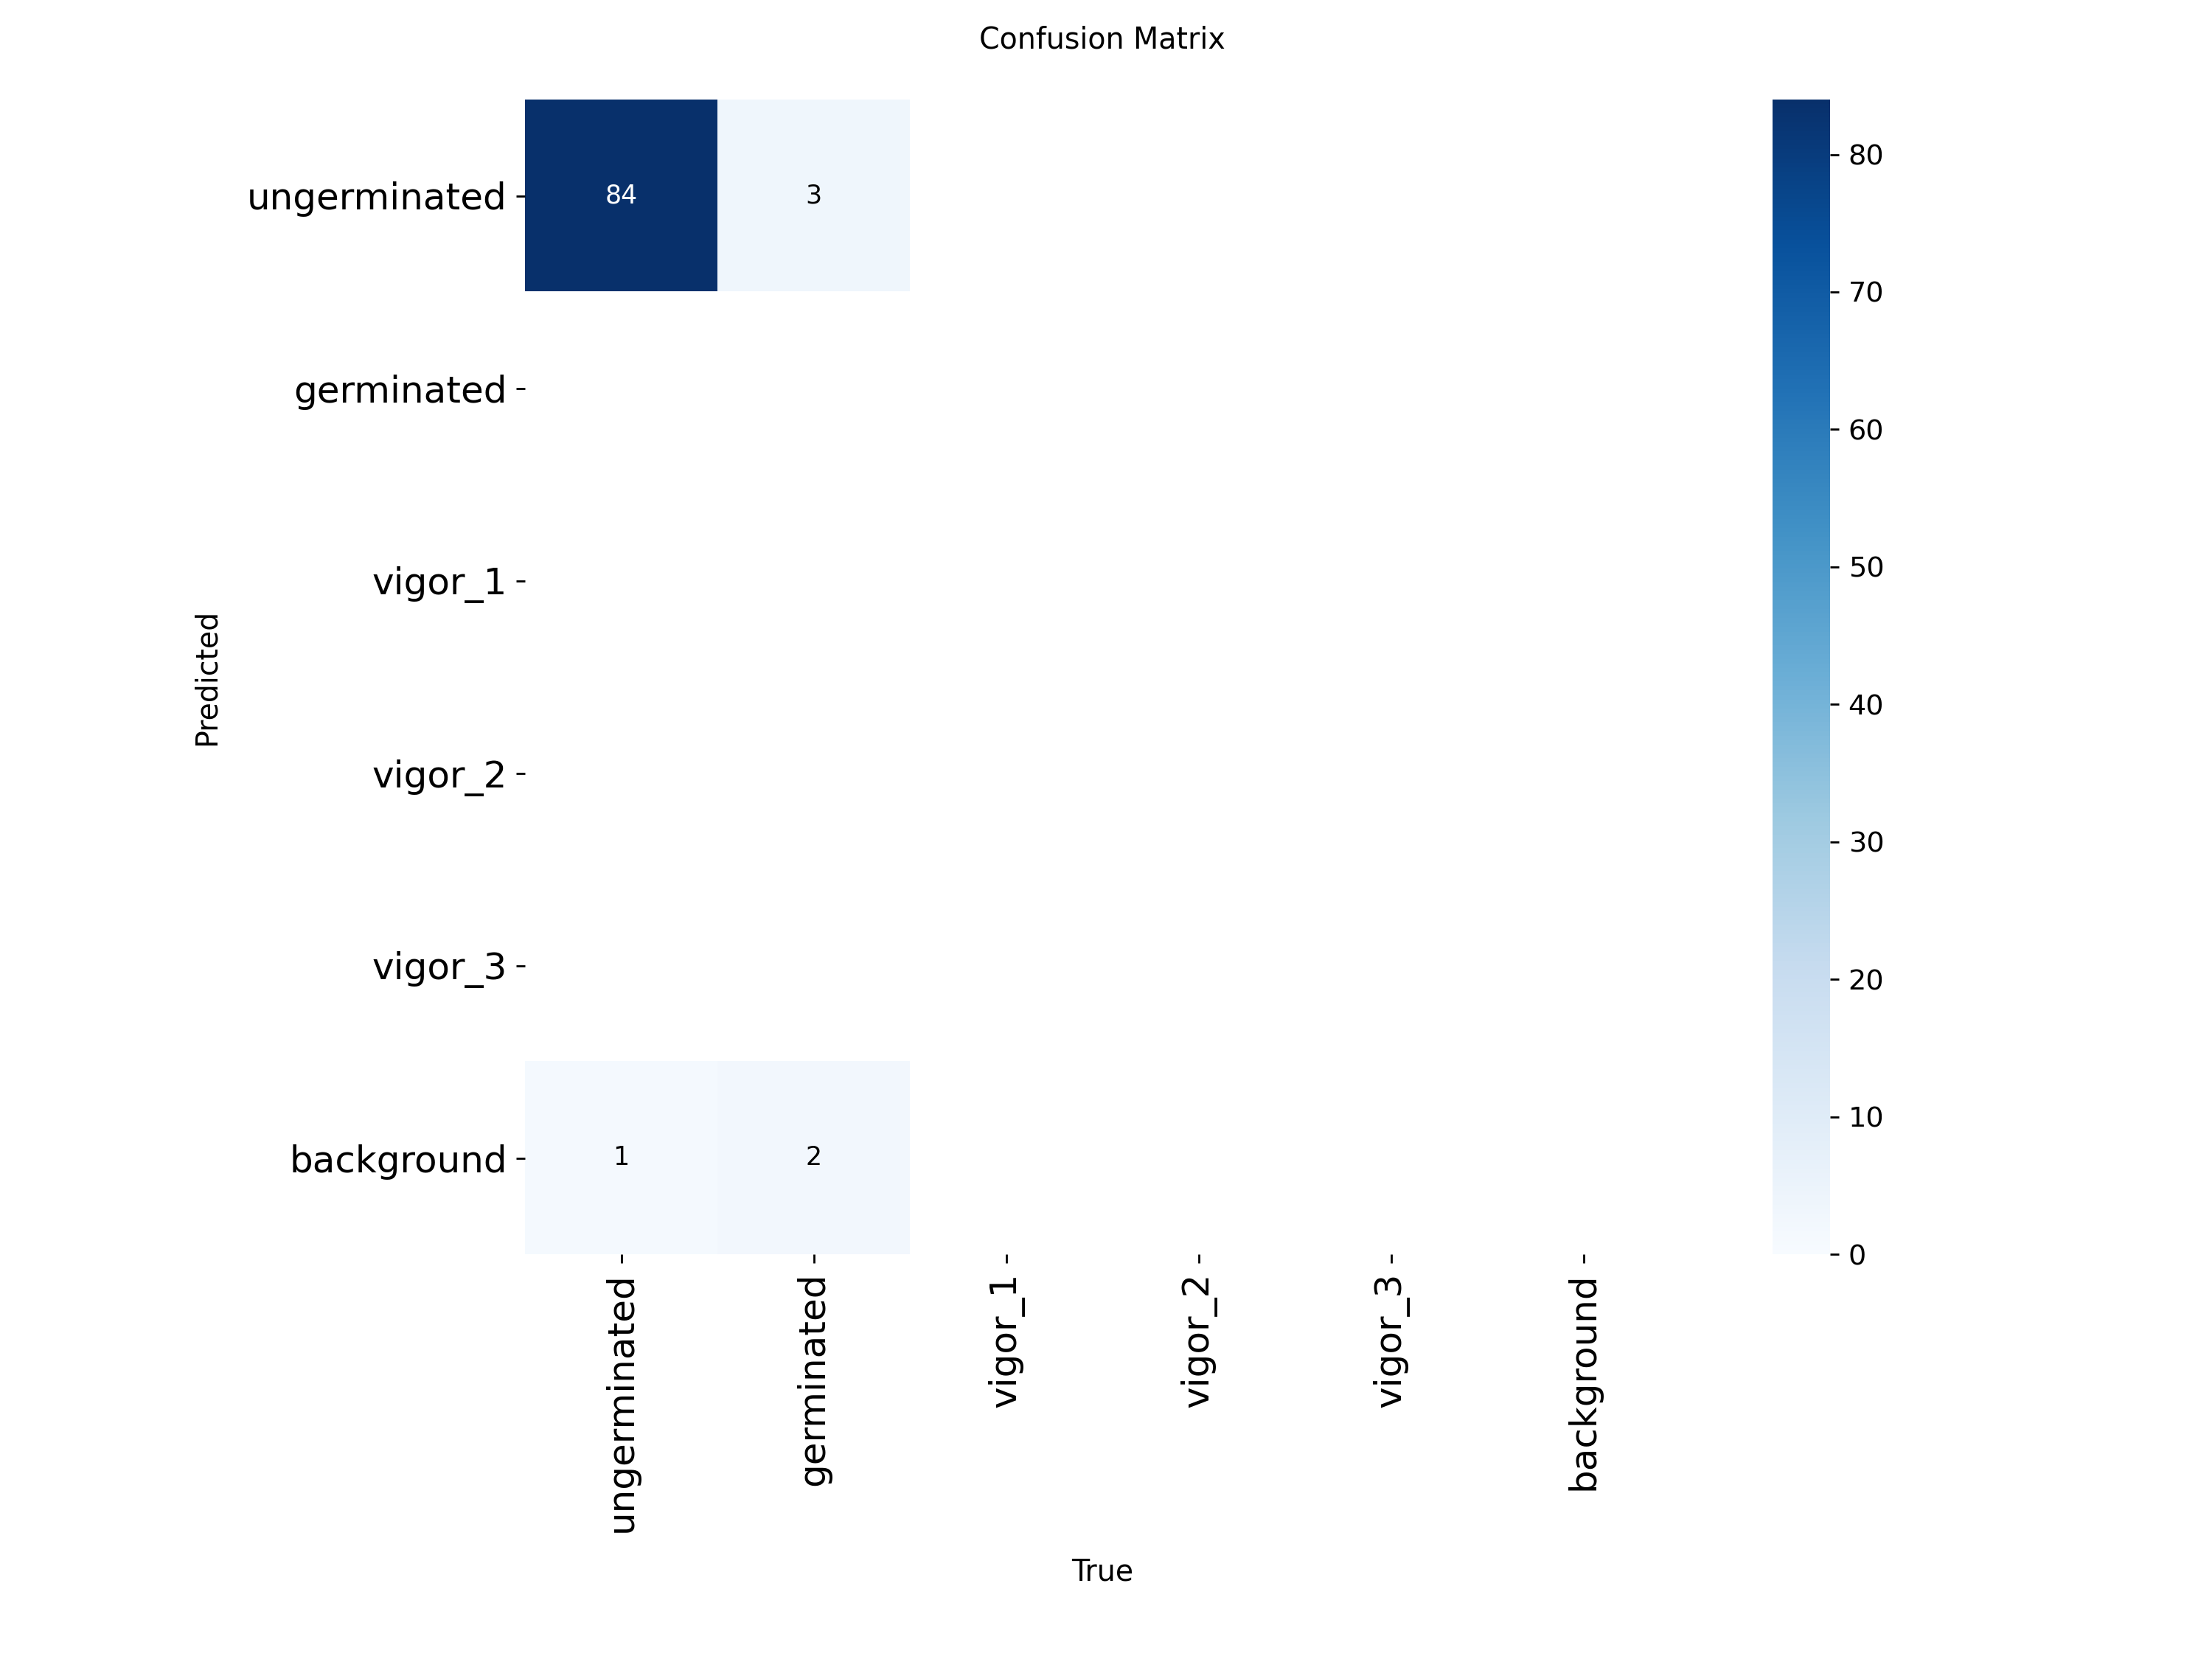


--- Normalized Confusion Matrix ---


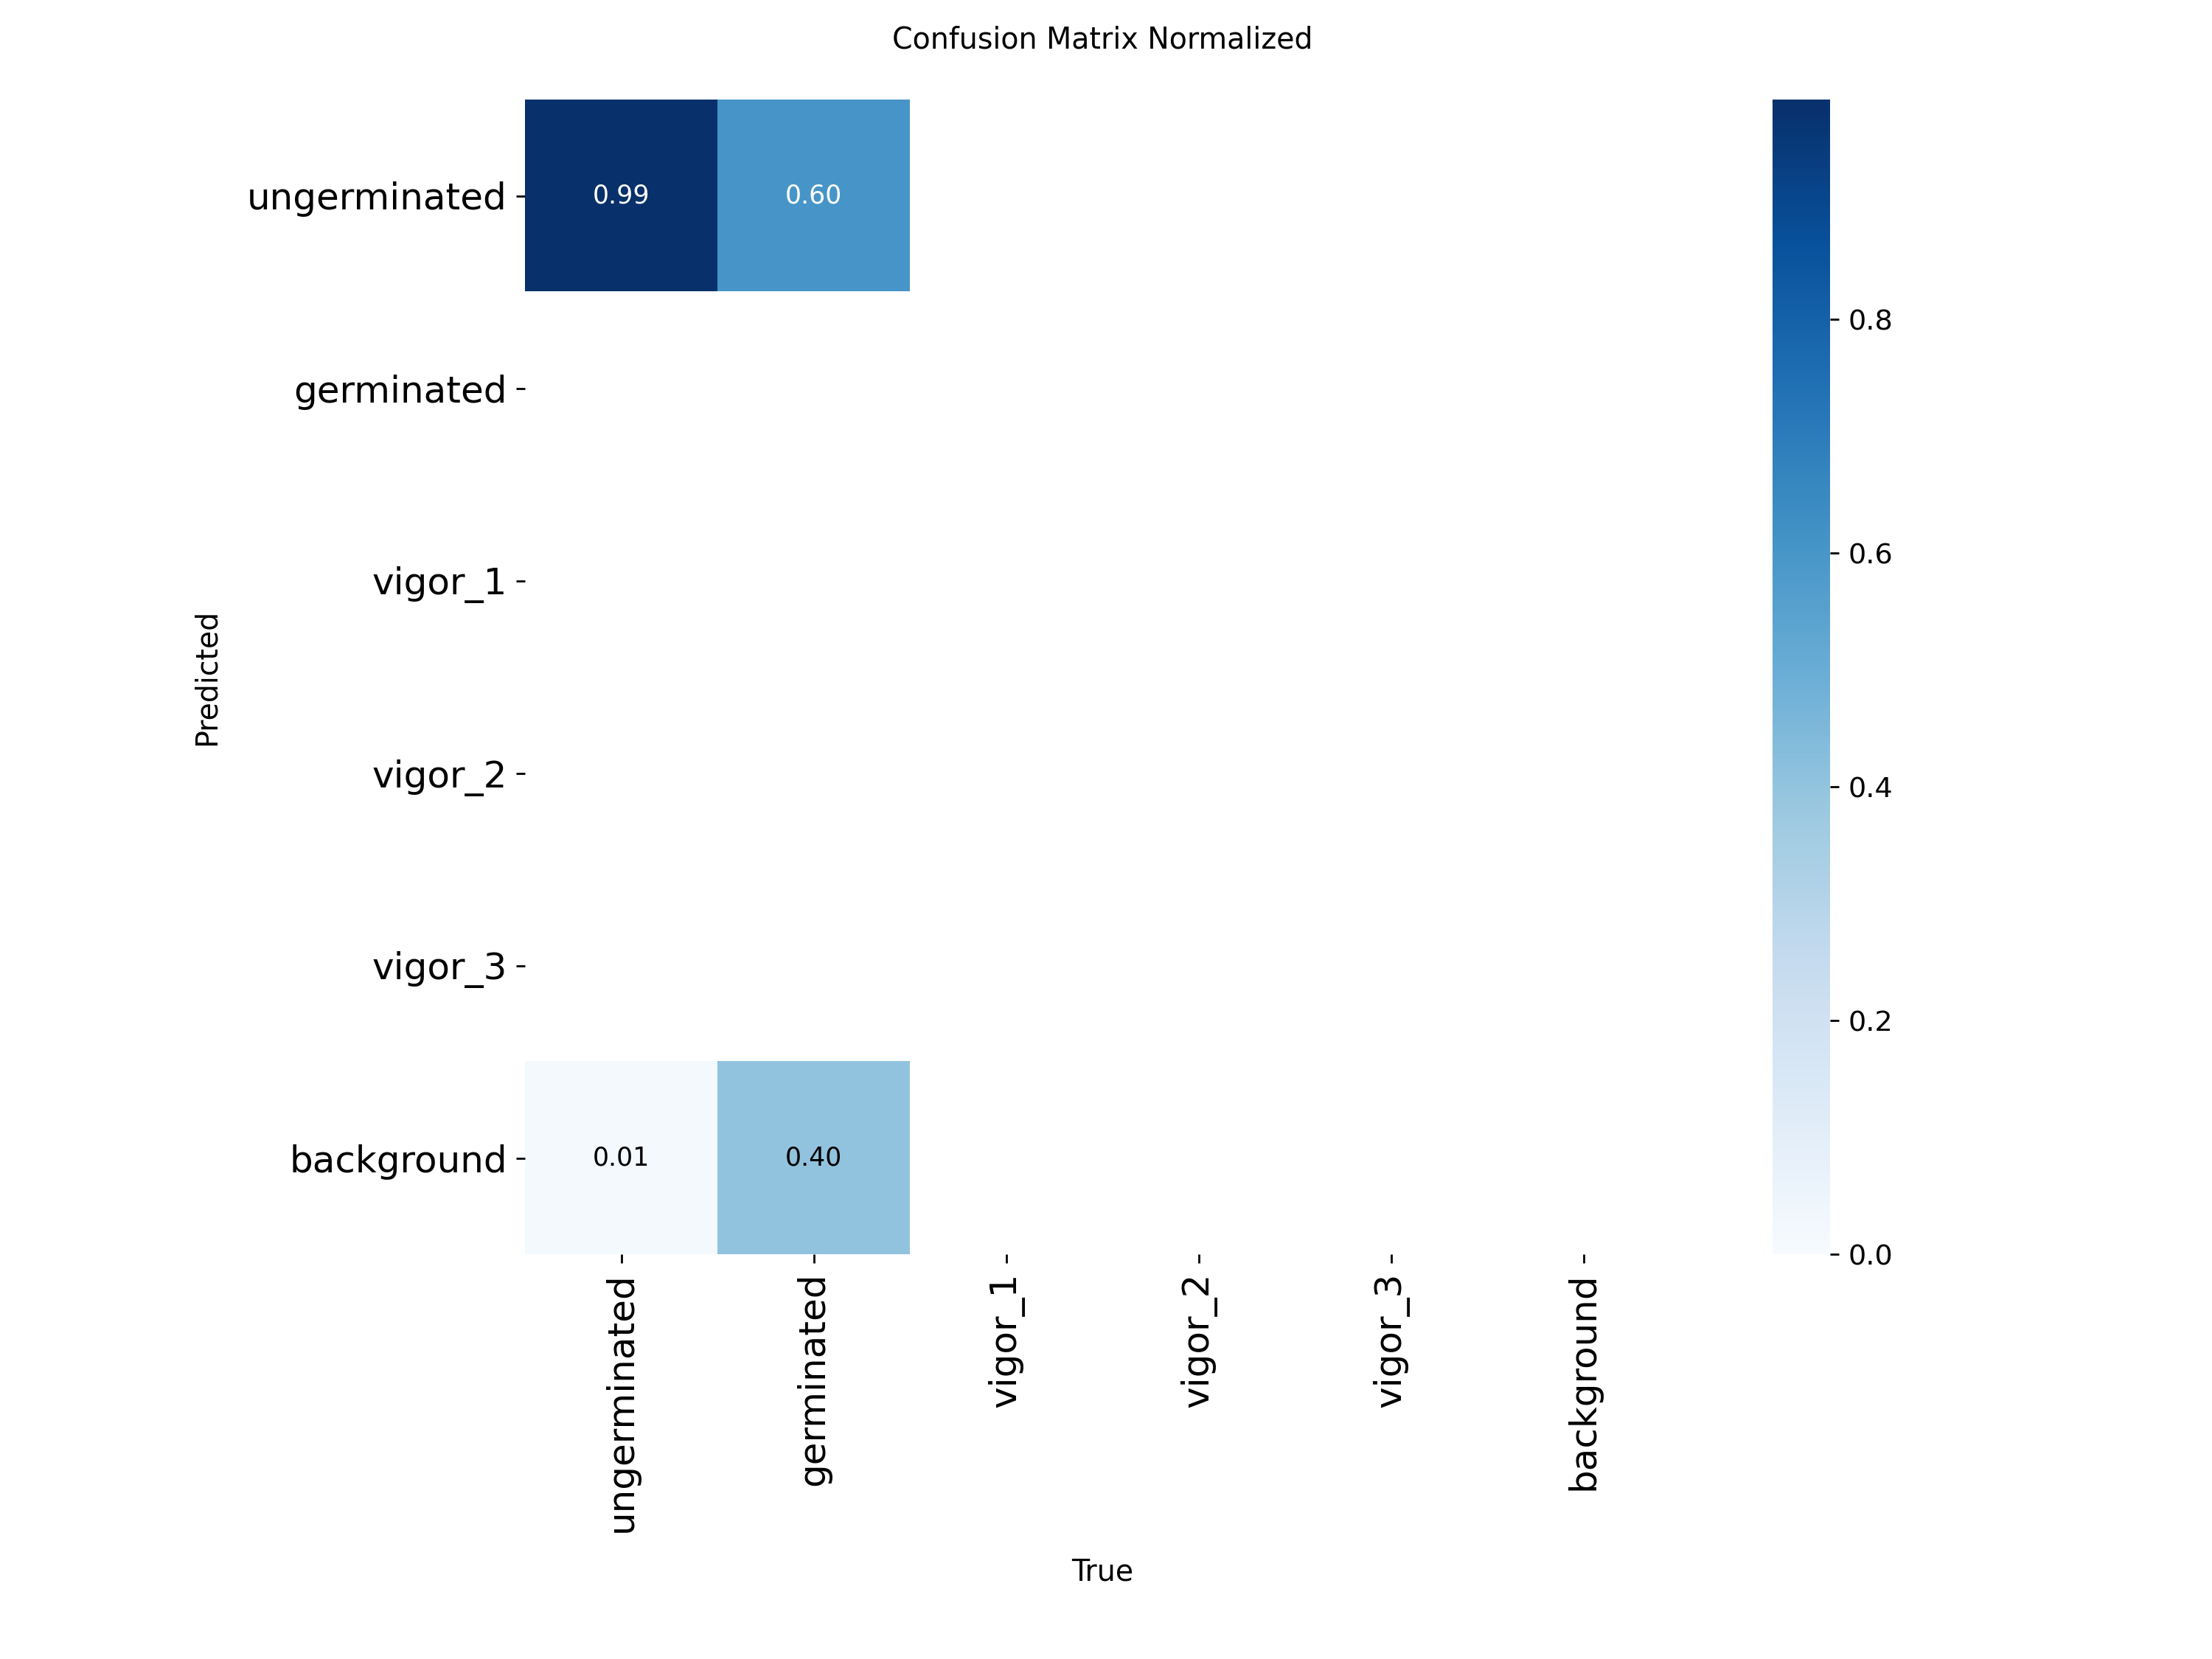

F1 Curve not found at: /content/runs/detect/val/F1_curve.png


In [ ]:
from IPython.display import Image, display
import os

# Use the save_dir from the validation metrics to find the plot files
results_dir = metrics.save_dir
print(f"Fetching results from: {results_dir}")

# 1. Print detailed metrics summary
print(f"--- Validation Metrics Summary ---")
print(f"Precision: {metrics.results_dict['metrics/precision(B)']:.4f}")
print(f"Recall:    {metrics.results_dict['metrics/recall(B)']:.4f}")
print(f"mAP50:     {metrics.results_dict['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95:  {metrics.results_dict['metrics/mAP50-95(B)']:.4f}")

# 2. Display the Confusion Matrices
# We check for both standard and normalized versions
cm_paths = [
    os.path.join(results_dir, 'confusion_matrix.png'),
    os.path.join(results_dir, 'confusion_matrix_normalized.png')
]

for path in cm_paths:
    if os.path.exists(path):
        title = "Normalized Confusion Matrix" if "normalized" in path else "Confusion Matrix"
        print(f"\n--- {title} ---")
        display(Image(filename=path, width=700))
    else:
        print(f"File not found: {path}")

# 3. Display the F1-Confidence Curve
f1_curve_path = os.path.join(results_dir, 'F1_curve.png')
if os.path.exists(f1_curve_path):
    print("\n--- F1-Confidence Curve ---")
    display(Image(filename=f1_curve_path, width=700))
else:
    print(f"F1 Curve not found at: {f1_curve_path}")